In [29]:
from enformer_pytorch import from_pretrained
import torch
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "MIG-f80e9374-504a-571b-bac0-6fb00750db4c" 
os.environ["WORLD_SIZE"] = "0"

enformer = from_pretrained('EleutherAI/enformer-official-rough', use_tf_gamma = False)

In [30]:
import pyfaidx
from tangermeme.utils import one_hot_encode
from tangermeme.utils import random_one_hot
from tangermeme.ersatz import substitute

import pyfaidx
from tangermeme.utils import one_hot_encode
from tangermeme.utils import random_one_hot
from tangermeme.ersatz import substitute

# pos0=5271188
# chrm = 'chr11'

pos0=155271420
chrm = 'chr1'

SEQLEN=196608*2

genome = pyfaidx.Fasta("/mnt/lab_data2/anusri/chrombpnet/reference/male.hg19.fa")
seq = genome[chrm][pos0-SEQLEN//2:pos0+SEQLEN//2].seq.upper()
X = one_hot_encode(seq).unsqueeze(0).float()
X.shape


# # pos0=5271075
# # allele='G'
# # chrm = 'chr11'

# pos0=155271272
# allele='G'
# altallele='C'
# chrm = 'chr1'

# genome = pyfaidx.Fasta("/mnt/lab_data2/anusri/chrombpnet/reference/male.hg19.fa")
# refseq = genome[chrm][pos0-SEQLEN//2:pos0].seq.upper() + allele + genome[chrm][pos0+1:pos0+SEQLEN//2].seq.upper()
# altseq = genome[chrm][pos0-SEQLEN//2:pos0].seq.upper() + altallele + genome[chrm][pos0+1:pos0+SEQLEN//2].seq.upper()

# refX = one_hot_encode(refseq).unsqueeze(0).float()
# refX.shape

# altX = one_hot_encode(altseq).unsqueeze(0).float()
# altX.shape

torch.Size([1, 4, 393216])

In [31]:
#refseq[SEQLEN//2-5:SEQLEN//2+5]

In [32]:
#altseq[SEQLEN//2-5:SEQLEN//2+5]

In [33]:
#torch.transpose(torch.tensor(refX), -2, -1).shape

In [34]:
#torch.transpose(torch.tensor(X), -2, -1).shape

In [35]:
refpred = enformer(torch.transpose(torch.tensor(X), -2, -1))['human'][0,:,122]
#altpred = enformer(torch.transpose(torch.tensor(altX), -2, -1))['human'][0,:,122]

/tmp/ipykernel_3426590/1106644631.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  refpred = enformer(torch.transpose(torch.tensor(X), -2, -1))['human'][0,:,122]


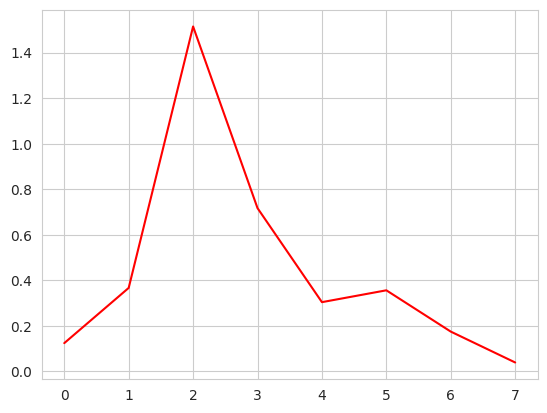

In [36]:
import matplotlib.pyplot as plt
plt.plot(refpred.detach().numpy()[896//2-4:896//2+4], c='r')
#plt.plot(altpred.detach().numpy()[896//2-4:896//2+4], c='b')


In [37]:
refpred.shape

torch.Size([896])

In [38]:
from tangermeme.ism import saturation_mutagenesis
import torch

#X = refX
class SliceWrapper(torch.nn.Module):
    def __init__(self, model, target):
        super(SliceWrapper, self).__init__()
        self.model = model
        self.target = target

    def forward(self, X):
        #print(X.shape)
        return self.model(torch.transpose(torch.tensor(X), -2, -1))['human'][:,:,self.target]


wrapper = SliceWrapper(enformer, target=121)
X_attr = saturation_mutagenesis(wrapper, X,  start=SEQLEN//2-150, end=SEQLEN//2+150,  device='cuda', batch_size=1, hypothetical=True)
#y0, yhat = saturation_mutagenesis(wrapper, X,  start=SEQLEN//2-100, end=SEQLEN//2+100,  device='cuda', batch_size=1, raw_outputs=True)
#
#X_attr.shape

/tmp/ipykernel_3426590/3568441071.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return self.model(torch.transpose(torch.tensor(X), -2, -1))['human'][:,:,self.target]


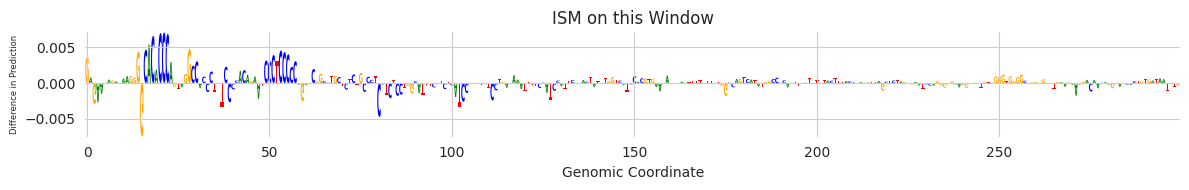

In [39]:
import matplotlib.pyplot as plt
import seaborn; seaborn.set_style('whitegrid')
from tangermeme.plot import plot_logo

plt.figure(figsize=(12, 2))
plot_logo((X_attr * X[:, :, SEQLEN//2-150:SEQLEN//2+150])[0])

plt.xlabel("Genomic Coordinate")
plt.ylabel("Difference in Prediction", fontsize=6)
plt.title("ISM on this Window")

plt.tight_layout()
plt.show()

In [40]:
import numpy as np
outfile="enformer_PKLR.npy"
np.save(outfile, X_attr)

In [ ]:
print(y0.shape)
y0n = y0[:, 444:452].sum(axis=-1)
yhatn= yhat[:,:,:,444:452].sum(axis=-1)

In [60]:
#yhat.shape


448

In [142]:
y0.shape

torch.Size([1, 896])

In [144]:
y0[:, 444:452].sum(axis=-1)

tensor([0.2191])

In [65]:
attr = yhatn[:, :, :, None] - y0n[:, None, None, None]
attr -= torch.mean(attr, dim=1, keepdims=True)

In [66]:
attr.shape

torch.Size([1, 4, 200, 1])

In [67]:
896//2

448

In [68]:
448-4

444

In [69]:
448+4

452

In [70]:
#attr = attr[:,:,:,:,444:452]

In [71]:
if len(attr.shape) > 3:
    attr = torch.mean(attr, dim=tuple(range(3, len(attr.shape))))

In [72]:
X_attr = attr

In [73]:
#y0

In [74]:
#yhat

In [77]:
#enformer(X.reshape((1,196608,4)).to('cuda'))['human'].shape

In [78]:
X_attr.shape

torch.Size([1, 4, 200])

In [79]:
X.shape

torch.Size([1, 4, 393216])

In [80]:
(X_attr * X[:, :, SEQLEN//2-100:SEQLEN//2+100])[0].shape

torch.Size([4, 200])

In [ ]:
import matplotlib.pyplot as plt
import seaborn; seaborn.set_style('whitegrid')
from tangermeme.plot import plot_logo

plt.figure(figsize=(12, 2))
plot_logo((X_attr * X[:, :, SEQLEN//2-100:SEQLEN//2+100])[0])

plt.xlabel("Genomic Coordinate")
plt.ylabel("Difference in Prediction", fontsize=6)
plt.title("ISM on this Window")

plt.tight_layout()
plt.show()

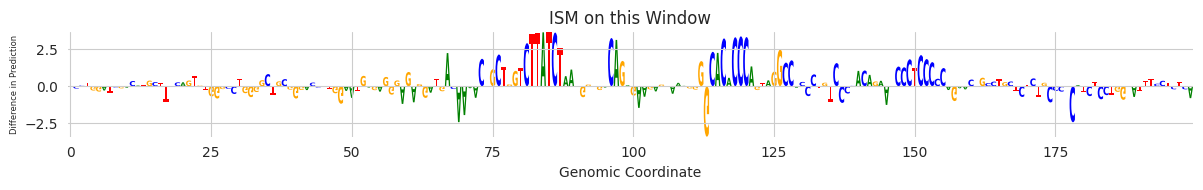

In [76]:
import matplotlib.pyplot as plt
import seaborn; seaborn.set_style('whitegrid')
from tangermeme.plot import plot_logo

plt.figure(figsize=(12, 2))
plot_logo((X_attr * X[:, :, SEQLEN//2-100:SEQLEN//2+100])[0])

plt.xlabel("Genomic Coordinate")
plt.ylabel("Difference in Prediction", fontsize=6)
plt.title("ISM on this Window")

plt.tight_layout()
plt.show()

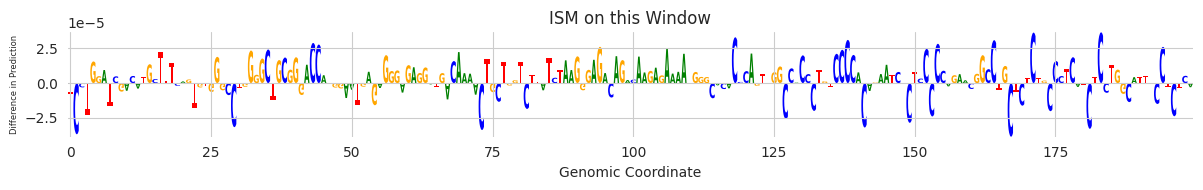

In [15]:

seq = genome[chrm][pos0-SEQLEN//2:pos0].seq.upper() + altallele + genome[chrm][pos0+1:pos0+SEQLEN//2].seq.upper()

X = one_hot_encode(seq).unsqueeze(0).float()
X.shape

from tangermeme.ism import saturation_mutagenesis
import torch

class SliceWrapper(torch.nn.Module):
    def __init__(self, model, target):
        super(SliceWrapper, self).__init__()
        self.model = model
        self.target = target

    def forward(self, X):
        #print(X.shape)
        return self.model(X.reshape((-1,SEQLEN,4)))['human'][:,self.target,:]


wrapper = SliceWrapper(enformer, target=121)
X_attr = saturation_mutagenesis(wrapper, X,  start=SEQLEN//2-100, end=SEQLEN//2+100,  device='cuda', batch_size=1)
X_attr.shape


import matplotlib.pyplot as plt
import seaborn; seaborn.set_style('whitegrid')
from tangermeme.plot import plot_logo

plt.figure(figsize=(12, 2))
plot_logo((X_attr * X[:, :, SEQLEN//2-100:SEQLEN//2+100])[0])

plt.xlabel("Genomic Coordinate")
plt.ylabel("Difference in Prediction", fontsize=6)
plt.title("ISM on this Window")

plt.tight_layout()
plt.show()